**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
  - 1.1. [Load Dataset](#toc1_1_)    
  - 1.2. [Configuration](#toc1_2_)    
- 2. [Xây dựng Vocab](#toc2_)    
- 3. [Transformer](#toc3_)    
  - 3.1. [Chuẩn bị dataset](#toc3_1_)    
  - 3.2. [Chuẩn bị model](#toc3_2_)    
  - 3.3. [Training](#toc3_3_)    
- 4. [Thử nghiệm:](#toc4_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Setup](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch

print(torch.__version__)
print(torch.version.cuda)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

!nvidia-smi

In [ ]:
# Kiểm tra root_dir trên Kaggle
import os
print(os.listdir("/kaggle/input/datasets/nostagiguideus17"))


# Thiết lập để import source code
import sys
sys.path.append("/kaggle/input/datasets/nostagiguideus17/abstractive-summary-vers-transformer")

input_path = "/kaggle/input/datasets/nostagiguideus17/abstractive-summary-vers-transformer"

## 1.1. <a id='toc1_1_'></a>[Load Dataset](#toc0_)

In [2]:
import pandas as pd
from datasets import Dataset

df = pd.read_csv('./data/train.csv')

# dataset = Dataset.from_parquet('.data/train-00000-of-00001.parquet')
# df = dataset.to_pandas()
# df.to_csv('train.csv', index=False, encoding="utf-8-sig")

df.head()

c:\Users\ngson\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,article,summary
0,Gần 20 sự kiện được tổ chức trên toàn thành ph...,Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...
1,"Được thành lập năm 1897 tại Đức, Kempinski Hot...",Kempinski Hotels là một thương hiệu nổi tiếng ...
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...",Bài viết giới thiệu các hoạt động vui chơi giả...
3,"Với những tín đồ Phật giáo, bức tượng Phật ngọ...","Bức tượng Phật ngọc hòa bình thế giới, được vợ..."
4,Số liệu của Tổng cục Thống kê công bố sáng 29/...,"Trong tháng 4, Việt Nam tiếp tục đón khách quố..."


## 1.2. <a id='toc1_2_'></a>[Configuration](#toc0_)

In [ ]:
from src.interfaces import ModelConfig
import torch

config = ModelConfig(
    lowercase = True, 
    dropout_prob = 0.1,

    vocab_size = 30000,
    embed_dim= 512,
    max_target_length = 1000,
    
    evaluation_config = {
            "rouge": {
                "rouge_types": ["rouge1", "rouge2", "rouge3", "rougeLsum"],
                "use_stemmer": True
            },
            "bertscore": {
                # Vì tóm tắt tiếng Việt, ta nên dùng PhoBERT để đo khoảng cách ngữ nghĩa
                "model_type": "vinai/phobert-base", 
                "num_layers": 4 # Tham số sâu của BERTScore (optional)
            }
        }
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# 2. <a id='toc2_'></a>[Xây dựng Vocab](#toc0_)

In [ ]:
from src.preprocess import BPETokenizer

tokenizer = BPETokenizer(config)

tokenizer.train_from_iterator(df["article"].tolist() + df["summary"].tolist())

tokenizer.save("/kaggle/working/tokenizer")

[Info] Đang huấn luyện BPE Tokenizer với vocab_size=30000...
[Info] Hoàn tất huấn luyện! Kích thước từ điển thực tế: 30000
ID của <PAD>: 0
[Info] Đã lưu cấu trúc Tokenizer và Vocab (CSV) tại: ./tokenizer\tokenizer_20260606_090351


,Token
ID,
0,<PAD>
1,<UNK>
2,<BOS>
3,<EOS>
4,!
...,...
29995,lshtm
29996,mfamobile
29997,otellini


In [ ]:
from src.preprocess import BPETokenizer

tokenizer = BPETokenizer.load(
    config = config,
    save_folder = input_path + "/model_save/transformer_v17/tokenizer"
)

[Info] Đã tải thành công Tokenizer từ: ./tokenizer/tokenizer_20260604_144223


In [ ]:
pad_id = tokenizer.token_to_id(tokenizer.special_tokens.pad_token)
print(f"ID của <PAD>: {pad_id}")

# 3. <a id='toc3_'></a>[Transformer](#toc0_)

## 3.1. <a id='toc3_1_'></a>[Chuẩn bị dataset](#toc0_)

In [9]:
from src.dataset import SummarizationDataset

train_dataset = SummarizationDataset(
    dataset=df,

    encode_fn=tokenizer.encode_batch, # Hàm mã hóa hàng loạt (batch encoding)
)

In [10]:
from torch.utils.data import DataLoader
from src.dataset import TransformerCollate


train_loader = DataLoader(
    train_dataset, 

    batch_size=16, 

    shuffle=True, 

    collate_fn= TransformerCollate(pad_id)
)

## 3.2. <a id='toc3_2_'></a>[Chuẩn bị model](#toc0_)

In [ ]:
from src.transformer import Transformer

transformer:Transformer = Transformer(
    vocab_size = config.vocab_size,
    d_model    = config.embed_dim,
    pad_id     = pad_id,

    nhead           = 8,
    num_encoder_layers  = 2,
    num_decoder_layers  = 4,
    dim_feedforward     = config.embed_dim * 4,
    
    dropout             = config.dropout_prob,
    seq_max_len         = config.max_target_length
)



In [ ]:
from src.transformer import Transformer

transformer, optimizer, scheduler = Transformer.load_state(input_path + "/model_save/transformer_v17/model_60_epochs")

## 3.3. <a id='toc3_3_'></a>[Training](#toc0_)

In [ ]:
from torch import nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

epochs = 60
save_interval = 10

transformer.to(device)

if not scheduler:
    total_steps = epochs * len(train_loader)
    warmup_steps = 0.1  # Dành 10% tổng số step đầu tiên để warmup (tăng dần LR từ 0)
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps = int(warmup_steps*total_steps), 
        num_training_steps = total_steps
    )

if not optimizer:
    optimizer = AdamW(transformer.parameters(), lr=1e-4, weight_decay=0.01)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.1)

loss_trajectory = []

In [ ]:
from tqdm import tqdm

for epoch in range(epochs):
    transformer.train()
    total_loss = 0
        
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
    for batch in progress_bar:

        source_ids, target_ids = [x.to(device) for x in batch]
        
        # 1. Target_label -> Nhãn để tính loss
        target_label = target_ids.clone()    # Nhãn để tính loss

        # 2. Target_input (Right-Shift) -> feed cho decoder học 
        # Kẹp thẻ PAD vào đầu để làm Start Token
        start_tokens = torch.full((target_ids.size(0), 1), transformer.pad_id, dtype=torch.long, device=device)
        # Cắt bỏ thẻ EOS ở cuối ([:, :-1]), và 
        target_input = torch.cat([start_tokens, target_ids[:, :-1]], dim=1)

        # Truyền vào mô hình
        optimizer.zero_grad()
        logits = transformer(source_ids=source_ids, target_ids=target_input)
            
        # Tính Loss
        loss = criterion(logits.view(-1, transformer.vocab_size), target_label.view(-1))
            
        loss.backward()
            
        # Cắt Gradient tránh bùng nổ
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
            
        optimizer.step()  # Cập nhật Gradient 
        scheduler.step()  # Cập nhật learning rate

        # Chỉnh record
        progress_bar.set_postfix(loss=loss.item())
            
        loss_trajectory.append(loss.item())
        total_loss += loss.item()
            
    avg_loss = total_loss / len(train_loader)
    print(f"Hoàn thành Epoch {epoch+1} | Average Loss: {avg_loss:.4f}\n")

    if ((epoch+1) % save_interval == 0):
        loss_series = pd.Series(loss_trajectory[:])
        save_dir = f"/kaggle/working/model/checkpoint_{epoch+1}_epochs"
        
        transformer.save_state(save_dir, optimizer, scheduler)
        loss_series.to_csv(save_dir + "/loss", index=False)

Epoch 1/2: 100%|██████████| 674/674 [22:41<00:00,  2.02s/it, loss=12.7]


Hoàn thành Epoch 1 | Average Loss: 21.0602



Epoch 2/2:  40%|███▉      | 269/674 [09:02<13:36,  2.02s/it, loss=10.5]


KeyboardInterrupt: 

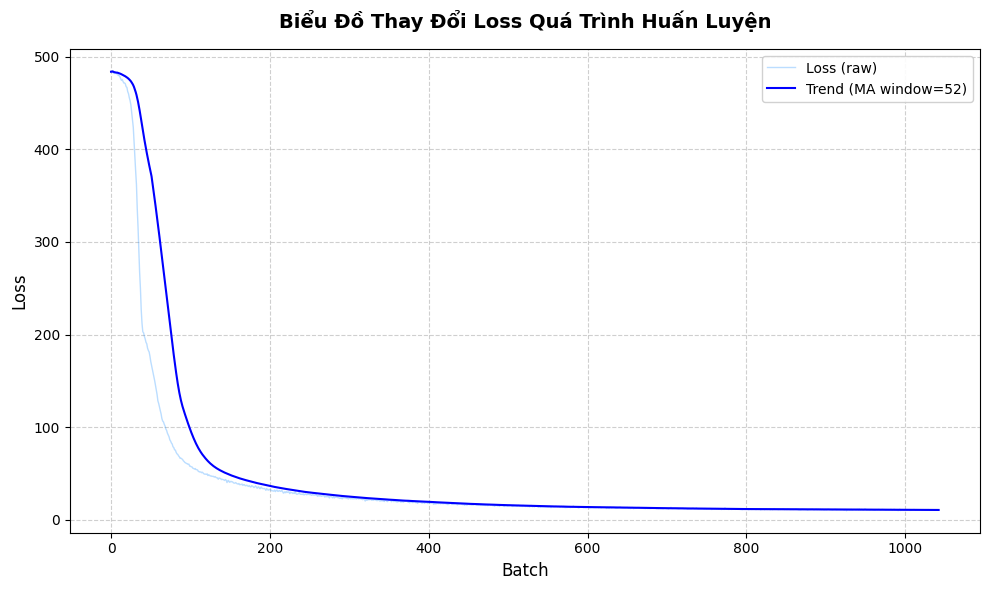

In [26]:
from src.visualize import visualizeLoss

visualizeLoss(pd.Series(loss_trajectory[:]))

# 4. <a id='toc4_'></a>[Thử nghiệm:](#toc0_)

In [23]:
input = df['article'].iloc[0]
expected_output = df['summary'].iloc[0]

In [ ]:
output = transformer.generate(
    source_ids=torch.tensor(tokenizer.encode(input), dtype=torch.long).unsqueeze(0),

    eos_id=tokenizer.token_to_id(tokenizer.special_tokens.eos_token),
    
    device=device
)

tokenizer.decode(output.cpu().numpy()[0], skip_special_tokens=False)

'<BOS>,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,ngườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingườingười

In [ ]:
expected_output

'Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5, bao gồm Lễ hội Du lịch Hà Nội 2024, các triển lãm và lễ hội văn hóa, nhằm thu hút cả du khách và người dân.  Song song đó, thành phố cũng đẩy mạnh các sản phẩm du lịch xanh và chuẩn bị chu đáo để đáp ứng nhu cầu tăng cao trong kỳ nghỉ lễ 5 ngày, kỳ vọng thu hút nhiều khách du lịch trong và ngoài nước.'